# 10 — Full Temporal Application: S2-only SVM over all available scenes (2019–2023)

**Author:** Florian Klaver

**Prerequisites:** Notebook 08 must have run and saved `models/s2only_svm.joblib`.

---

Applies the best S2-only model (SVM + morphological postprocessing) to every
consecutive TIF pair in `data/Sentinel_CH/` that falls within the mowing season
(April – October) and has a gap ≤ 15 days. Cloud-masked and grassland-filtered
via `prepare_scene_features` from `src/evaluation.py`.

**Outputs** go to `data/operational_results/full_application/`:
- `mowed_<before>_to_<after>.tif` — postprocessed prediction raster (−1/0/1)
- `pred_<before>_to_<after>.tif` — raw prediction raster (before postprocessing)
- `run_summary.csv` — per-pair status, valid pixels, mowed pixels
- `mowed_area_timeseries.png` — mowed area (ha) bar chart over time

---
## 1. Setup & Imports

In [1]:
import sys
import os
import importlib
import numpy as np
import pandas as pd
import rasterio
import joblib
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

sys.path.insert(0, os.path.abspath('..'))

import src.evaluation
import src.postprocessing
import src.config
importlib.reload(src.evaluation)
importlib.reload(src.postprocessing)
importlib.reload(src.config)

from src.evaluation import FEATURE_NAMES, prepare_scene_features, run_prediction
from src.postprocessing import postprocess_prediction
from src.config import (
    S2_SCENES_DIR, AV_LANDUSE_PATH, AV_FIREBRIGADE_PATH,
    MODELS_DIR, RESULTS_DIR, PP_DISK_RADIUS, PP_MIN_AREA_PX,
)

OUTPUT_DIR = RESULTS_DIR / 'full_application'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'S2 scenes dir:  {S2_SCENES_DIR}')
print(f'Models dir:     {MODELS_DIR}')
print(f'Output dir:     {OUTPUT_DIR}')
print(f'PP disk_radius: {PP_DISK_RADIUS}  min_area_px: {PP_MIN_AREA_PX}')
print('Setup complete.')

S2 scenes dir:  C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\Sentinel_CH
Models dir:     C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\models
Output dir:     C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\operational_results\full_application
PP disk_radius: 2  min_area_px: 4
Setup complete.


---
## 2. Build Scene Pairs

Discover all `YYYY-MM-DD.tif` files, sort by date, and form consecutive pairs.
Pairs are kept only when:
- Both dates fall within the mowing season (`SEASON_START_MONTH`–`SEASON_END_MONTH`)
- The gap between acquisitions is ≤ `MAX_GAP_DAYS` (avoids bridging winter or multi-year data gaps)

In [2]:
# ── Parameters ──────────────────────────────────────────────────────────────
MAX_GAP_DAYS        = 15   # maximum days between before/after scene
SEASON_START_MONTH  = 4    # April (inclusive)
SEASON_END_MONTH    = 10   # October (inclusive)
# ────────────────────────────────────────────────────────────────────────────

tif_files = sorted(S2_SCENES_DIR.glob('*.tif'))
dates     = [datetime.strptime(f.stem, '%Y-%m-%d').date() for f in tif_files]

pairs = []
for i in range(len(dates) - 1):
    d_before, d_after = dates[i], dates[i + 1]
    gap = (d_after - d_before).days
    in_season = (SEASON_START_MONTH <= d_before.month <= SEASON_END_MONTH and
                 SEASON_START_MONTH <= d_after.month  <= SEASON_END_MONTH)
    if in_season and gap <= MAX_GAP_DAYS:
        pairs.append({
            'before_date': d_before,
            'after_date':  d_after,
            'before_path': str(tif_files[i]),
            'after_path':  str(tif_files[i + 1]),
            'gap_days':    gap,
        })

pairs_df = pd.DataFrame(pairs)

print(f'Total TIF files:   {len(tif_files)}  ({dates[0]} → {dates[-1]})')
print(f'Candidate pairs:   {len(pairs_df)}  '
      f'(season {SEASON_START_MONTH}–{SEASON_END_MONTH}, gap ≤ {MAX_GAP_DAYS} days)')
print()
print(pairs_df[['before_date', 'after_date', 'gap_days']].to_string(index=False))

Total TIF files:   201  (2019-03-01 → 2023-09-16)
Candidate pairs:   168  (season 4–10, gap ≤ 15 days)

before_date after_date  gap_days
 2019-04-02 2019-04-05         3
 2019-04-05 2019-04-07         2
 2019-04-07 2019-04-10         3
 2019-04-10 2019-04-12         2
 2019-04-12 2019-04-15         3
 2019-04-15 2019-04-17         2
 2019-04-17 2019-04-20         3
 2019-04-20 2019-04-22         2
 2019-04-22 2019-04-25         3
 2019-04-25 2019-04-27         2
 2019-04-27 2019-04-30         3
 2019-04-30 2019-05-02         2
 2019-05-02 2019-05-05         3
 2019-05-05 2019-05-07         2
 2019-05-07 2019-05-10         3
 2019-05-10 2019-05-12         2
 2019-05-12 2019-05-15         3
 2019-05-15 2019-05-17         2
 2019-05-17 2019-05-20         3
 2019-05-20 2019-05-25         5
 2019-05-25 2019-05-27         2
 2019-05-27 2019-05-30         3
 2019-05-30 2019-06-01         2
 2019-06-01 2019-06-04         3
 2019-06-04 2019-06-06         2
 2019-06-06 2019-06-09         3
 2019

---
## 3. Load Model

Loads `s2only_svm.joblib` from the models directory.
The scene-calibrated threshold (0.82) from nb09 LOO calibration is used instead of the
artifact's PR-curve threshold (~0.29), which over-predicts at real scene class balance.

In [3]:
artifact = joblib.load(MODELS_DIR / 's2only_svm.joblib')
model   = artifact['model']
feat_s2 = artifact['features']

# Scene-calibrated threshold from nb09 Section 3.5 LOO calibration.
# Update this value if nb09 is re-run with different calibration scenes.
MODEL_THRESHOLD = 0.82

print(f'Model type:  {type(model).__name__}')
print(f'Features:    {feat_s2}')
print(f'Threshold:   {MODEL_THRESHOLD}  '
      f'(artifact stored: {artifact.get("threshold", "n/a"):.4f} — not used here)')

Model type:  Pipeline
Features:    ['ndii_diff', 'ndvi_diff', 'savi_diff', 'ndii_after', 'gndvi_after']
Threshold:   0.82  (artifact stored: 0.2855 — not used here)


---
## 4. Processing Loop

For each pair:
1. `prepare_scene_features` — grassland mask + airport mask + cloud mask + all vegetation indices
2. Skip if fewer than `MIN_VALID_FRACTION` of pixels survive masking (very cloudy scene)
3. `run_prediction` — apply SVM with calibrated threshold, write raw GeoTIFF
4. `postprocess_prediction` — morphological open/close + minimum area filter
5. Write postprocessed GeoTIFF and record stats in summary

In [ ]:
MIN_VALID_FRACTION = 0.05  # skip pair if < 5% of pixels are valid after cloud masking

summary_rows = []

for idx, row in pairs_df.iterrows():
    before_str = str(row['before_date'])
    after_str  = str(row['after_date'])
    label      = f'{before_str}_to_{after_str}'
    out_raw    = OUTPUT_DIR / f'pred_{label}.tif'
    out_pp     = OUTPUT_DIR / f'mowed_{label}.tif'

    # --- Prepare features -------------------------------------------------
    try:
        fdf, vmask, meta, H, W = prepare_scene_features(
            row['before_path'], row['after_path'],
            str(AV_LANDUSE_PATH), str(AV_FIREBRIGADE_PATH),
            FEATURE_NAMES)
    except Exception as e:
        print(f'  ERROR {label}: {e}')
        summary_rows.append({**row, 'status': 'error', 'n_valid': 0, 'n_mowed': 0})
        continue

    valid_fraction = vmask.sum() / (H * W)
    if valid_fraction < MIN_VALID_FRACTION:
        print(f'  SKIP  {label}  valid={valid_fraction:.1%}  (too cloudy)')
        summary_rows.append({**row, 'status': 'skipped_cloud',
                              'n_valid': int(vmask.sum()), 'n_mowed': 0})
        continue

    # --- Predict (raw) ----------------------------------------------------
    avail_feats = [f for f in feat_s2 if f in fdf.columns]
    run_prediction(model, fdf[avail_feats], vmask, H, W,
                   str(out_raw), meta, threshold=MODEL_THRESHOLD)

    # --- Postprocess ------------------------------------------------------
    with rasterio.open(str(out_raw)) as src:
        pred_map = src.read(1)
        pp_meta  = src.meta.copy()

    pred_pp = postprocess_prediction(pred_map, method='morphological',
                                     disk_radius=PP_DISK_RADIUS,
                                     min_area_pixels=PP_MIN_AREA_PX)

    with rasterio.open(str(out_pp), 'w', **pp_meta) as dst:
        dst.write(pred_pp, 1)

    n_valid = int(vmask.sum())
    n_mowed = int((pred_pp[pred_pp >= 0] == 1).sum())
    pct     = 100 * n_mowed / max(n_valid, 1)
    print(f'  OK    {label}  '
          f'valid={n_valid:,}  mowed={n_mowed:,}  ({pct:.1f}%)')
    summary_rows.append({**row, 'status': 'ok',
                          'n_valid': n_valid, 'n_mowed': n_mowed})

# --- Save summary ---------------------------------------------------------
summary_df = pd.DataFrame(summary_rows)
csv_path   = OUTPUT_DIR / 'run_summary.csv'
summary_df.to_csv(csv_path, index=False)

print(f'\n{"="*60}')
print(f'Done.  Processed: {(summary_df.status=="ok").sum()} / {len(summary_df)} pairs')
print(f'Skipped (cloud):  {(summary_df.status=="skipped_cloud").sum()}')
print(f'Errors:           {(summary_df.status=="error").sum()}')
print(f'Summary saved →   {csv_path}')
print()
print(summary_df[['before_date', 'after_date', 'gap_days',
                   'status', 'n_valid', 'n_mowed']].to_string(index=False))

---
## 5. Summary Visualisation

Bar chart of detected mowed area (ha) per pair over time, coloured by year.

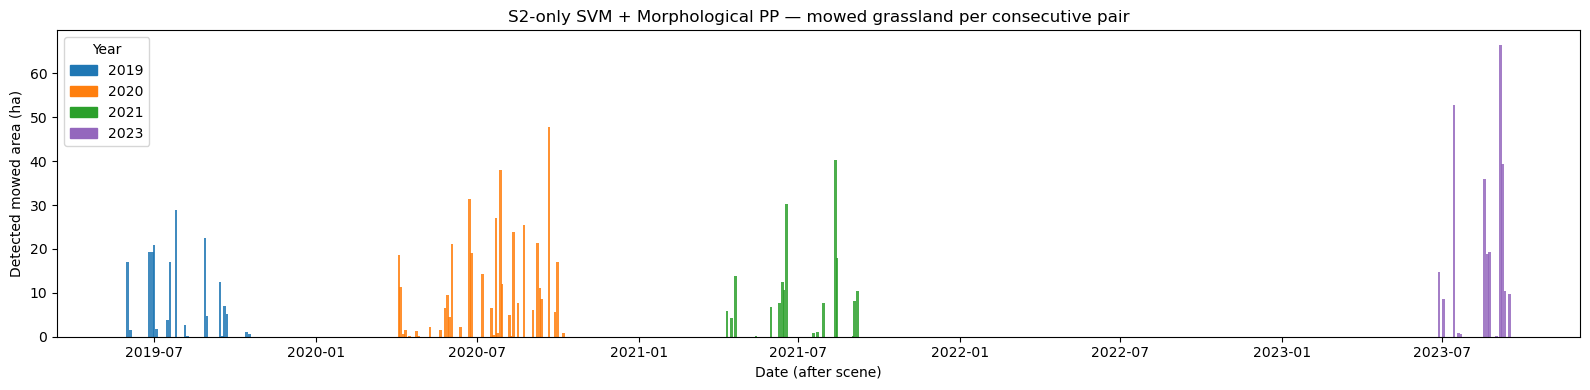

Saved: C:\Workspace\ZHAW\6_Semester\satellite-mowing-detection\data\operational_results\full_application\mowed_area_timeseries.png

=== Mowed area statistics per year ===
      n_pairs  mean_ha  max_ha  total_ha
year                                    
2019       20      9.3    28.9     186.1
2020       42      9.8    47.8     411.0
2021       22      8.1    40.2     178.5
2023       14     19.9    66.5     278.2


In [5]:
ok = summary_df[summary_df['status'] == 'ok'].copy()
ok['after_dt'] = pd.to_datetime(ok['after_date'])
ok['mowed_ha'] = ok['n_mowed'] * (10 * 10) / 10_000   # 10 m pixels → ha

year_colors = {2019: '#1f77b4', 2020: '#ff7f0e',
               2021: '#2ca02c', 2022: '#d62728', 2023: '#9467bd'}

fig, ax = plt.subplots(figsize=(16, 4))

for _, r in ok.iterrows():
    year  = r['after_dt'].year
    color = year_colors.get(year, 'grey')
    ax.bar(r['after_dt'], r['mowed_ha'], width=3, color=color, alpha=0.85)

ax.set_xlabel('Date (after scene)')
ax.set_ylabel('Detected mowed area (ha)')
ax.set_title('S2-only SVM + Morphological PP — mowed grassland per consecutive pair')

from matplotlib.patches import Patch
present_years = sorted(ok['after_dt'].dt.year.unique())
ax.legend(handles=[Patch(color=year_colors.get(y, 'grey'), label=str(y))
                   for y in present_years], title='Year')

plt.tight_layout()
out_png = OUTPUT_DIR / 'mowed_area_timeseries.png'
plt.savefig(out_png, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_png}')

# --- Quick stats per year ---
print('\n=== Mowed area statistics per year ===')
ok['year'] = ok['after_dt'].dt.year
print(ok.groupby('year')['mowed_ha'].agg(['count', 'mean', 'max', 'sum']).round(1).rename(
    columns={'count': 'n_pairs', 'mean': 'mean_ha', 'max': 'max_ha', 'sum': 'total_ha'}).to_string())

---
## 6. Visualise a Single Result

Visualising: 2019-07-24_to_2019-07-26  (mowed=2,889 px)


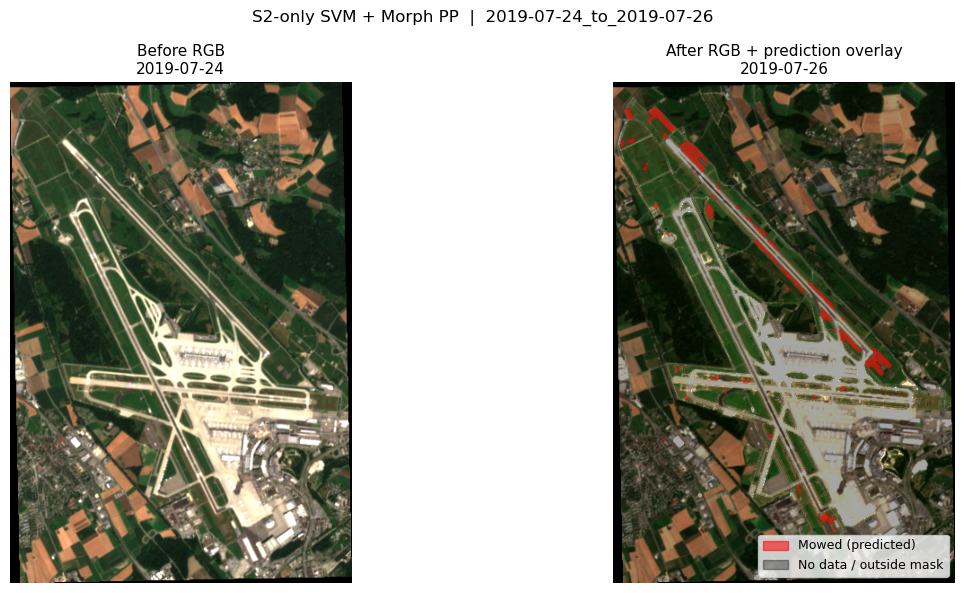

In [12]:
# ── Choose which pair to inspect ─────────────────────────────────────────
# Set to any after_date string from run_summary.csv, e.g. '2019-05-15'
# Leave as None to pick the pair with the most mowed pixels automatically.
VIZ_AFTER_DATE = '2019-07-26'   # e.g. '2020-05-29'
# ─────────────────────────────────────────────────────────────────────────

if VIZ_AFTER_DATE is None:
    row_viz = ok.loc[ok['n_mowed'].idxmax()]
else:
    row_viz = ok[ok['after_date'].astype(str) == VIZ_AFTER_DATE].iloc[0]

before_str = str(row_viz['before_date'])
after_str  = str(row_viz['after_date'])
label      = f'{before_str}_to_{after_str}'
pred_path  = OUTPUT_DIR / f'mowed_{label}.tif'

print(f'Visualising: {label}  (mowed={int(row_viz["n_mowed"]):,} px)')

# Load prediction
with rasterio.open(pred_path) as src:
    pred = src.read(1).astype(float)

def _load_rgb(path):
    with rasterio.open(path) as src:
        r = np.clip(src.read(3).astype(float) / 2500, 0, 1)
        g = np.clip(src.read(2).astype(float) / 2500, 0, 1)
        b = np.clip(src.read(1).astype(float) / 2500, 0, 1)
    return np.dstack([r, g, b])

rgb_before = _load_rgb(row_viz['before_path'])
rgb_after  = _load_rgb(row_viz['after_path'])

# Prediction overlay: mowed=red, nodata=semi-dark
overlay = np.zeros((*pred.shape, 4), dtype=float)
overlay[pred == 1]  = [1, 0, 0, 0.55]
overlay[pred == -1] = [0, 0, 0, 0.35]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: before RGB
axes[0].imshow(rgb_before)
axes[0].set_title(f'Before RGB\n{before_str}', fontsize=11)
axes[0].axis('off')

# Right: after RGB + prediction overlay
axes[1].imshow(rgb_after)
axes[1].imshow(overlay)
axes[1].set_title(f'After RGB + prediction overlay\n{after_str}', fontsize=11)
axes[1].axis('off')

from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color='red',   alpha=0.55, label='Mowed (predicted)'),
                         Patch(color='black', alpha=0.35, label='No data / outside mask')],
               loc='lower right', fontsize=9)

plt.suptitle(f'S2-only SVM + Morph PP  |  {label}', fontsize=12)
plt.tight_layout()
plt.show()

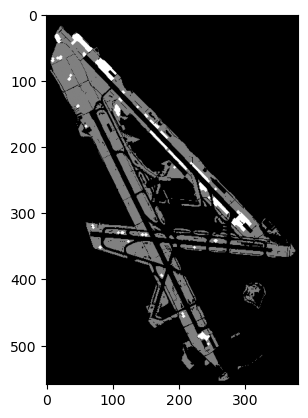

In [14]:
# visualize only a .tif file without RGB

import matplotlib.pyplot as plt

with rasterio.open(pred_path) as src:
    # Read the first band (assuming it's a single-band image)
    band = src.read(1)

plt.imshow(band, cmap='gray')
plt.show()
